# 02 주기 전처리와 A16 특징 생성


## 실행 준비

한글 그림에는 맑은 고딕·Noto Sans CJK KR·나눔고딕·AppleGothic 중 사용 가능한 글꼴이 필요하다. 

In [1]:
from pathlib import Path
import sys

sys.dont_write_bytecode = True
working_dir = Path.cwd().resolve()
root = (
    working_dir if (working_dir / "src" / "paths.py").is_file() else working_dir.parent
)
sys.path.insert(0, str(root / "src"))
from IPython.display import display, Image

## 주기·라벨·기간 선택

COMP=0 가동 시작 → 휴지 → 다음 가동 시작을 완전 주기로 정의한다. 센서기록이 30초 초과 공백인 경우 주기도 나눠준다. A16은 가동 2구간·휴지 5구간의 압력·전류 표본 평균 14개에 **전체 주기 길이(초)**를 곱한 값과 가동·휴지 시간 2개다. 양성은 가장 가까운 다음 고장 시작 2시간 전~24시간 전이다.

In [2]:
from preprocess import run_preprocessing, output_paths
from features import A16

result = run_preprocessing()
display(result["summary"])
display(result["flow"][["stage", "unit", "before", "excluded", "remaining"]])

,split,all_cycles,eligible,positive,first_end,last_end,eligible_hours
0,train,2314,2314,0,2020-03-01 04:32:22,2020-04-28 03:16:30,961.864444
1,validation,2754,2648,434,2020-05-01 22:24:14,2020-06-29 23:41:13,896.029722
2,july,1948,1845,182,2020-07-01 00:07:44,2020-07-31 23:55:05,545.715833


,stage,unit,before,excluded,remaining
0,raw_sensor_rows,rows,1516948,0,1516948
1,source_valid_rows,rows,1516948,0,1516948
2,COMP_run_segments,run segments,16967,6698,10269
3,complete_cycles_Feb_July,cycles,10269,1890,8379
4,training_mature,cycles,2476,17,2459
5,training_normal_guard,cycles,2459,145,2314
6,validation_mature,cycles,2821,67,2754
7,validation_metric_eligible,cycles,2754,106,2648
8,July_mature,cycles,1948,0,1948
9,July_metric_eligible,cycles,1948,103,1845


## 후속 단계 입력

`cycle_id`로 특징·라벨 표와 기간 선택표를 연결한다. 원본 21개 고장 기록의 중첩·인접 구간을 합치는 규칙은 유지한다. 

In [3]:
display(
    result["labeled"][
        ["cycle_id", "cycle_start", "cycle_end", "category", "eligible"] + A16
    ].head(3)
)
display(result["episodes"])
display(result["record_links"].head())

,cycle_id,cycle_start,cycle_end,category,eligible,TP3_B1,TP3_B2,TP3_B3,TP3_B4,TP3_B5,...,TP3_B7,MC_B1,MC_B2,MC_B3,MC_B4,MC_B5,MC_B6,MC_B7,Trun_seconds,Tidle_seconds
0,cycle_0000140,2020-02-01 00:23:08,2020-02-01 00:57:19,background,True,17457.428333,19911.108,20000.531600,19115.951077,18307.646718,...,16872.262256,11774.449167,12688.5115,7913.527125,482.773846,81.777051,81.908526,80.725256,109.0,1942.0
1,cycle_0000347,2020-02-01 00:57:19,2020-02-01 01:30:41,background,True,17122.705600,19303.284,19467.961333,18627.345579,17849.729333,...,16465.712421,11829.818000,12364.3520,7688.963333,481.665395,79.695000,79.816579,79.026316,99.0,1903.0
2,cycle_0000549,2020-02-01 01:30:41,2020-02-01 02:04:23,background,True,17165.971200,19423.332,19687.436308,18821.916615,18019.856615,...,16603.174105,11993.493000,12405.9810,7925.332692,690.590769,78.935769,77.250769,80.081842,99.0,1923.0


,episode_id,start,end_exclusive,event_ids
0,episode_01,2020-04-12 11:50:00,2020-04-12 23:31:00,#1
1,episode_02,2020-04-18 00:00:00,2020-04-19 01:31:00,#2|#3
2,episode_03,2020-04-29 03:20:00,2020-04-29 04:01:00,#4
3,episode_04,2020-04-29 22:00:00,2020-04-29 22:21:00,#5
4,episode_05,2020-05-13 14:00:00,2020-05-14 00:00:00,#6
5,episode_06,2020-05-18 05:00:00,2020-05-18 05:31:00,#7
6,episode_07,2020-05-19 10:10:00,2020-05-19 11:01:00,#8
7,episode_08,2020-05-19 22:10:00,2020-05-20 20:01:00,#9|#10
8,episode_09,2020-05-23 09:50:00,2020-05-23 10:11:00,#11
9,episode_10,2020-05-29 23:30:00,2020-05-30 06:01:00,#12|#13


,event_id,failure_start,failure_end,duration_minutes_reported,severity,end_exclusive_record,episode_id,start,end_exclusive_episode
0,#1,2020-04-12 11:50:00,2020-04-12 23:30:00,700,high,2020-04-12 23:31:00,episode_01,2020-04-12 11:50:00,2020-04-12 23:31:00
1,#2,2020-04-18 00:00:00,2020-04-18 23:59:00,1440,high,2020-04-19 00:00:00,episode_02,2020-04-18 00:00:00,2020-04-19 01:31:00
2,#3,2020-04-19 00:00:00,2020-04-19 01:30:00,90,high,2020-04-19 01:31:00,episode_02,2020-04-18 00:00:00,2020-04-19 01:31:00
3,#4,2020-04-29 03:20:00,2020-04-29 04:00:00,40,high,2020-04-29 04:01:00,episode_03,2020-04-29 03:20:00,2020-04-29 04:01:00
4,#5,2020-04-29 22:00:00,2020-04-29 22:20:00,20,high,2020-04-29 22:21:00,episode_04,2020-04-29 22:00:00,2020-04-29 22:21:00


## 그림 01 전처리 집계

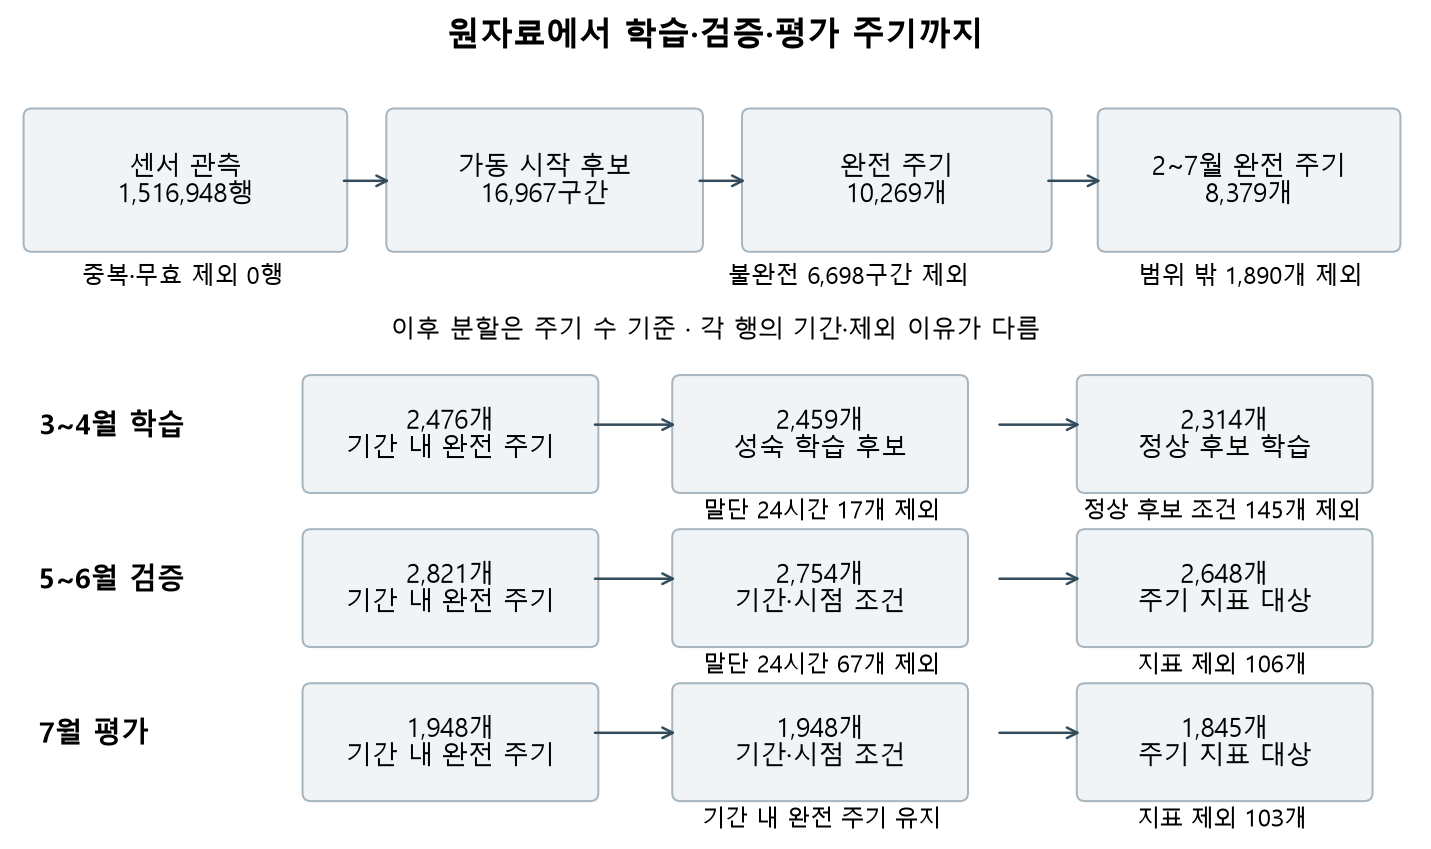

In [4]:
display(Image(filename=str(output_paths()["figure01"])))

## 그림 02 정상 주기와 7구간

학습 정상 후보 중 주기 길이가 중앙값에 가장 가까운 주기를 선택하고 동률은 이른 종료 시각으로 정한다.

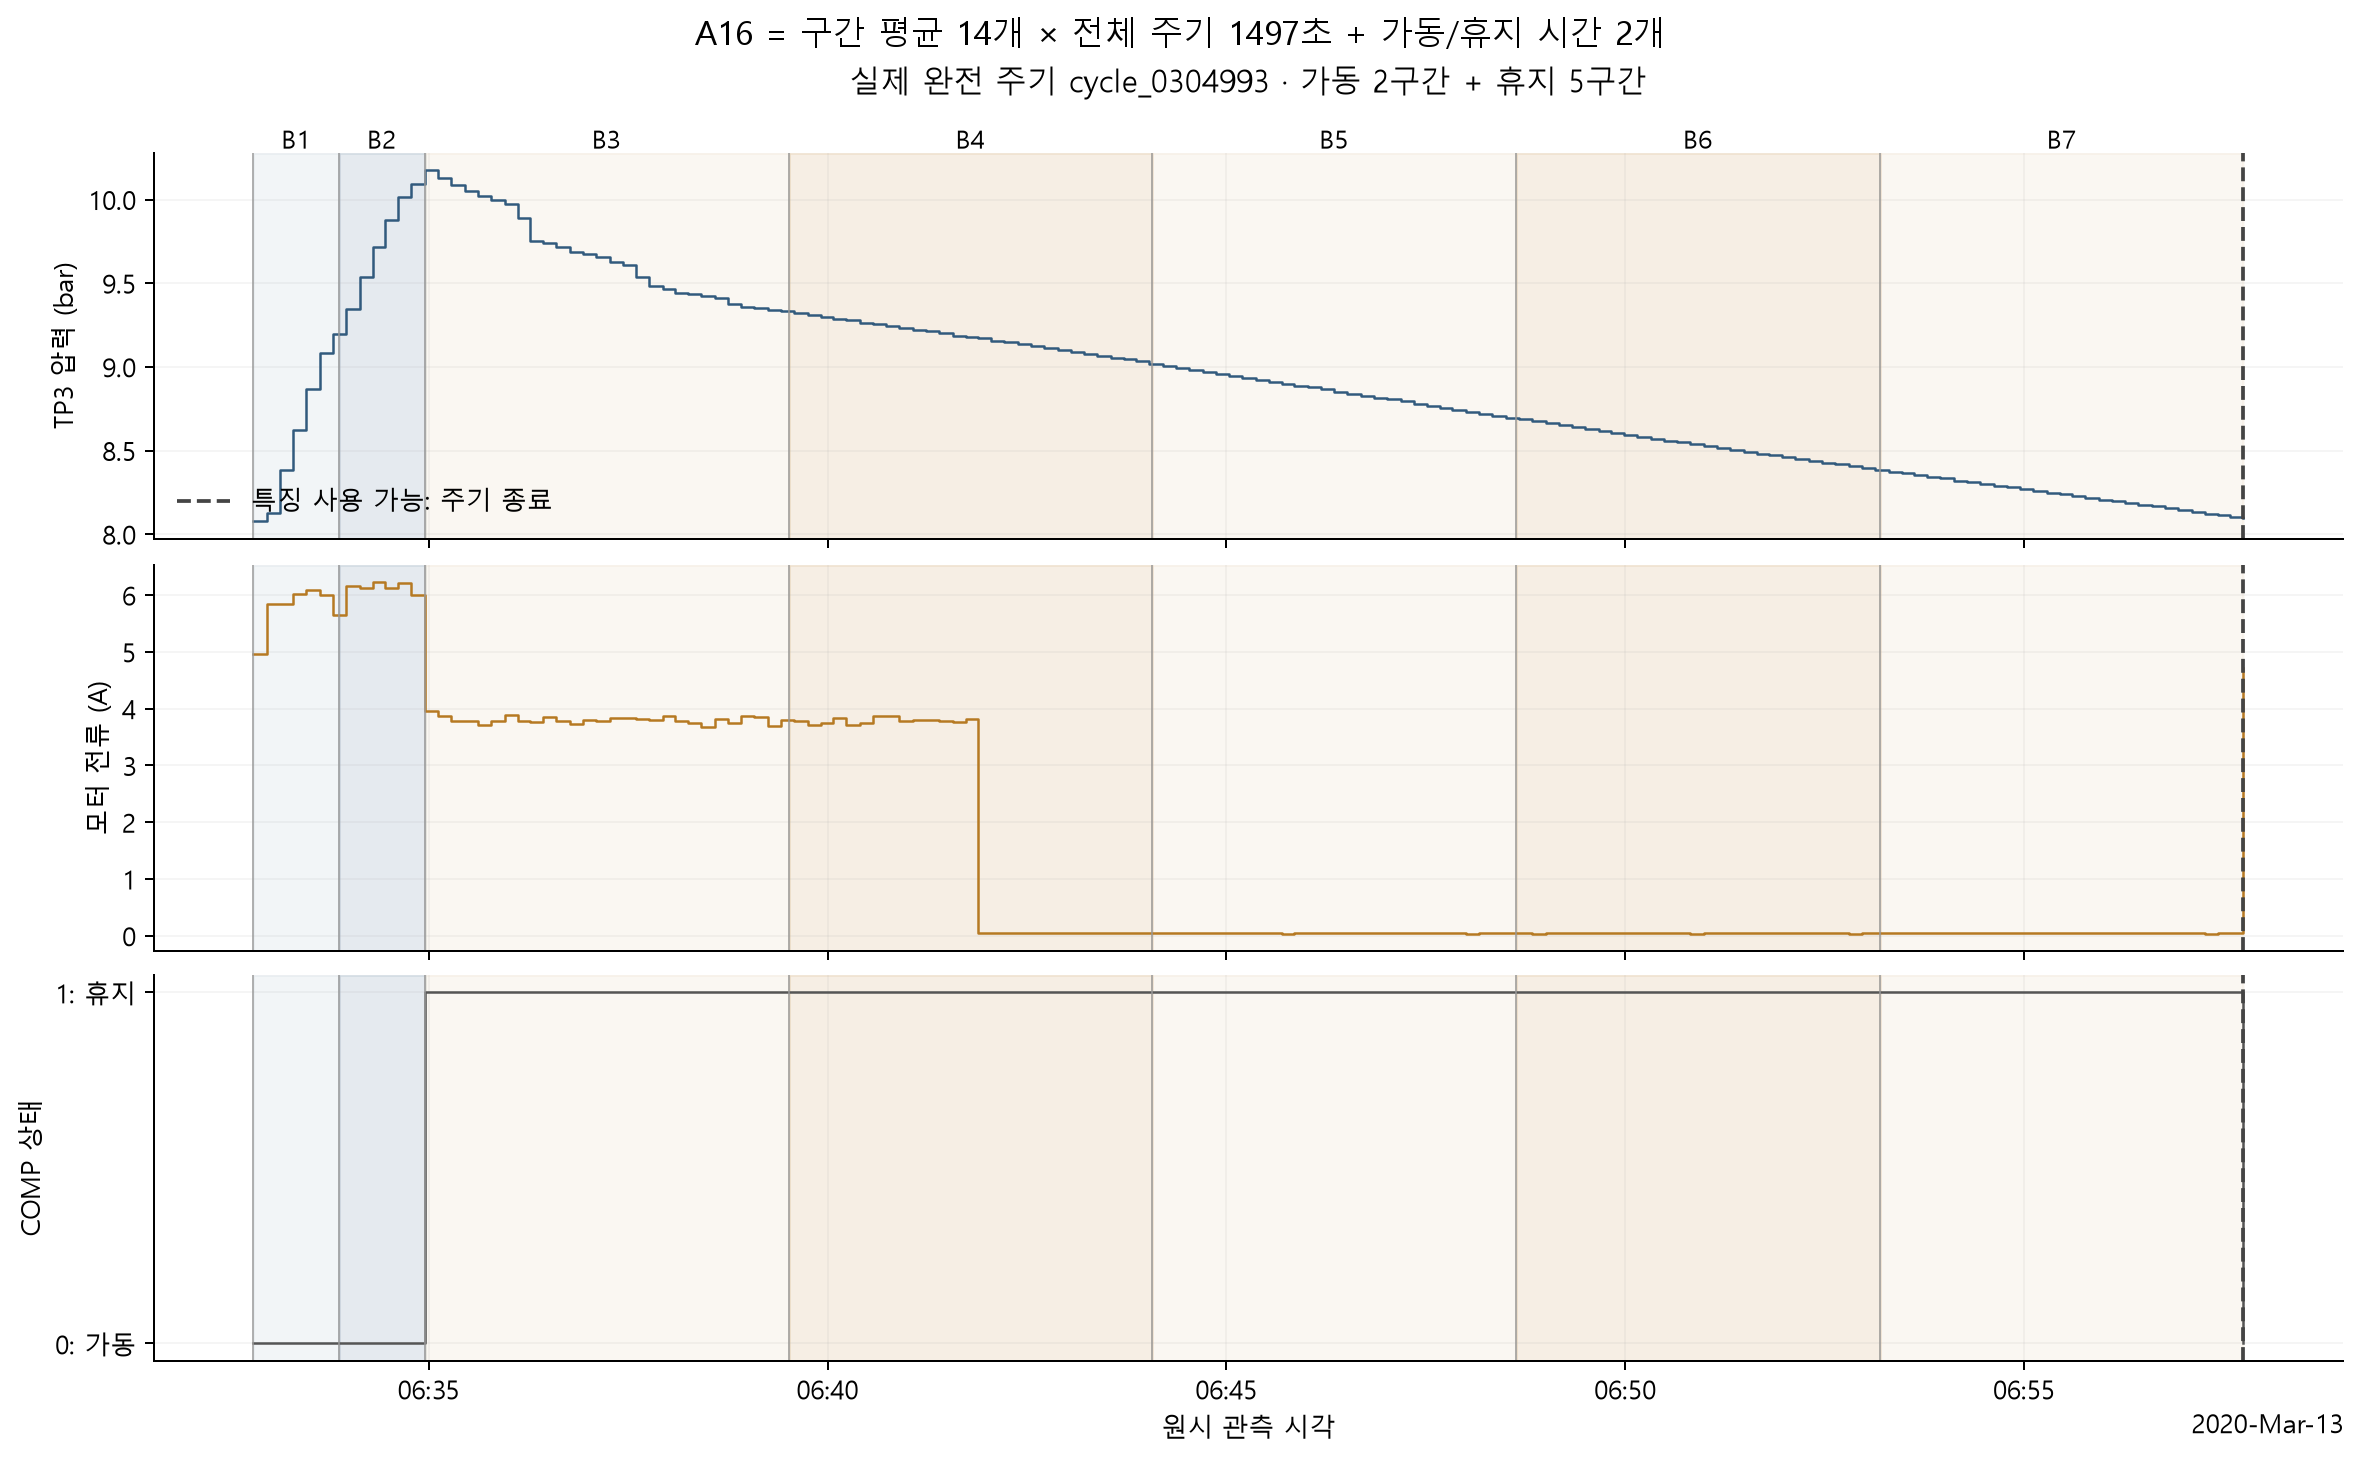

In [5]:
display(Image(filename=str(output_paths()["figure02"])))

In [6]:
display(result["example_values"])

,bin,sensor,samples,sample_mean,whole_cycle_seconds,A16_value
0,B1,TP3,7,8.622000,1497.0,12907.134000
1,B1,Motor_current,7,5.773214,1497.0,8642.501786
2,B2,TP3,6,9.764333,1497.0,14617.207000
3,B2,Motor_current,6,6.142500,1497.0,9195.322500
4,B3,TP3,28,9.669429,1497.0,14475.134571
5,B3,Motor_current,28,3.802500,1497.0,5692.342500
6,B4,TP3,28,9.171786,1497.0,13730.163214
7,B4,Motor_current,28,1.915089,1497.0,2866.888661
8,B5,TP3,27,8.851778,1497.0,13251.111333
9,B5,Motor_current,27,0.042315,1497.0,63.345278
